In [1]:
import jax
import jax.numpy as jnp
from jax import random
import os
# do not preallocate GPU memory (jax)
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = 'false'


def sample_checkerboard_shifted(
    key: jax.Array,
    n: int,
    *,
    tiles_x: int = 8,
    tiles_y: int = 8,
    parity: str = "even",     # which tiles are "filled": (i + j) % 2 == 0 or 1
    shift_frac: float = 0.5,  # horizontal shift (in tile widths) for every odd row
) -> jnp.ndarray:
    """
    Samples exactly `n` points from a staggered-row checkerboard in [-1, 1]^2.
    - Filled tiles satisfy (i + j) % 2 == p, where p=0 ('even') or 1 ('odd').
    - Every odd row (j % 2 == 1) is shifted by `shift_frac * tile_width`.
    - No rejection; uniform within each chosen tile; no vertical corridors.

    Args:
        key: jax.random.PRNGKey
        n: number of samples
        tiles_x, tiles_y: number of tiles per axis (even recommended)
        parity: 'even' or 'odd'
        shift_frac: row shift as a fraction of tile width (0.5 = brick pattern)

    Returns:
        (n, 2) samples in [-1, 1]^2
    """
    if tiles_x < 2 or tiles_y < 2:
        raise ValueError("tiles_x and tiles_y must be >= 2.")
    if parity not in ("even", "odd"):
        raise ValueError("parity must be 'even' or 'odd'.")
    if not (0.0 <= shift_frac < 1.0):
        raise ValueError("shift_frac must be in [0, 1).")

    key_j, key_a, key_u, key_v = random.split(key, 4)
    p = 0 if parity == "even" else 1

    # --- 1) Sample ALL rows uniformly: j in {0,...,tiles_y-1}
    j = random.randint(key_j, (n,), 0, tiles_y)

    # --- 2) Enforce (i + j) % 2 == p by choosing i's parity from j
    # Desired i_parity = (p - (j % 2)) mod 2
    j_par = j & 1
    i_par = (p ^ j_par).astype(jnp.int32)  # XOR == addition mod 2

    # Sample the "half-grid" column index a, then lift to full-grid i = 2*a + i_par
    half_x = (tiles_x + 1) // 2  # works for even/odd tiles_x
    a = random.randint(key_a, (n,), 0, half_x)
    i = 2 * a + i_par
    # If tiles_x is odd, i can equal tiles_x on the last a when i_par=1; clip it.
    i = jnp.minimum(i, tiles_x - 1)

    # --- 3) Geometry
    w = 2.0 / tiles_x
    h = 2.0 / tiles_y

    # Uniform offsets inside the tile
    u = random.uniform(key_u, (n,), minval=0.0, maxval=1.0)
    v = random.uniform(key_v, (n,), minval=0.0, maxval=1.0)

    # Base corners
    x0 = -1.0 + i.astype(jnp.float32) * w
    y0 = -1.0 + j.astype(jnp.float32) * h

    # --- 4) Shift every odd row horizontally by shift_frac * w (then wrap)
    row_is_odd = (j & 1).astype(jnp.float32)
    x = x0 + row_is_odd * (shift_frac * w) + u * w
    y = y0 + v * h

    # Wrap on torus to keep all points in [-1, 1]^2 (robust near boundaries)
    x = -1.0 + jnp.mod(x + 1.0, 2.0)
    y = -1.0 + jnp.mod(y + 1.0, 2.0)

    return jnp.stack([x, y], axis=-1)


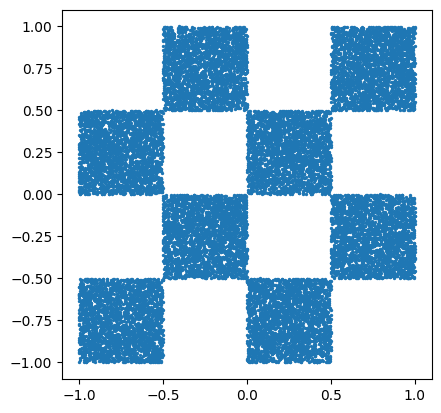

In [ ]:
from matplotlib import pyplot as plt
from jax import random

key = random.PRNGKey(0)
X = sample_checkerboard_shifted(key, 20_000, tiles_x=4, tiles_y=4, parity="even", shift_frac=0.0)

plt.scatter(X[:,0], X[:,1], s=2)
plt.gca().set_aspect("equal")
plt.show()

In [2]:
import jax
import jax.numpy as jnp
from jax import random
import os
# do not preallocate GPU memory (jax)
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = 'false'

def sample_rings_jax(
    key: jax.Array,
    n: int,
    *,
    c: float = 0.2,                 # constant spacing between successive radii
    r1: float | None = None,        # inner radius; if None we set r4=r_max and back off
    r_max: float = 0.95,            # ensure r4 <= r_max < 1 to stay inside [-1,1]^2
    probs=(0.4, 0.3, 0.2, 0.1),     # priors for rings 1..4 (inner→outer); will be normalized
    radial_std: float = 0.0,        # radial thickness (0 = infinitesimally thin ring)
    enforce_proportions: bool = True # if True, match exact counts to probs
) -> jnp.ndarray:
    """
    Return exactly `n` samples from 4 concentric rings centered at the origin, all within [-1,1]^2.

    Radii: r_i = r1 + (i-1)*c, i=1..4, with r4 <= r_max < 1.
    Priors: probs (inner→outer). If enforce_proportions, the sample counts per ring
            match probs exactly (up to rounding).

    Args:
        key: jax.random.PRNGKey
        n: number of points
        c: spacing between rings
        r1: inner radius; if None, set r4=r_max and r1=r_max-3c
        r_max: maximum allowed radius to ensure bounds
        probs: length-4 nonnegative ring weights (inner→outer)
        radial_std: std dev of radial noise (Gaussian along radial direction)
        enforce_proportions: control exact counts per ring

    Returns:
        (n,2) JAX array of (x,y) samples in [-1,1]^2.
    """
    probs = jnp.array(probs, dtype=jnp.float32)
    probs = probs / jnp.sum(probs)
    if jnp.any(probs < 0) or probs.shape[0] != 4:
        raise ValueError("`probs` must be length-4 and nonnegative.")
    if c <= 0:
        raise ValueError("`c` must be > 0.")
    if r1 is None:
        r1 = r_max - 3.0 * c
    if r1 <= 0 or (r1 + 3.0 * c) > r_max or r_max >= 1.0:
        raise ValueError("Invalid radii: need 0 < r1 and r1+3c <= r_max < 1.")

    r = jnp.array([r1 + k * c for k in range(4)], dtype=jnp.float32)  # [r1, r2, r3, r4]

    # Decide how many points per ring
    if enforce_proportions:
        # Deterministic rounding with largest-remainder method
        raw = probs * n
        k_floor = jnp.floor(raw).astype(jnp.int32)
        rem = n - jnp.sum(k_floor)
        # assign leftover to the largest fractional parts
        frac = raw - k_floor.astype(jnp.float32)
        order = jnp.argsort(-frac)  # descending
        add = jnp.zeros(4, dtype=jnp.int32).at[order[:rem]].add(1) if rem > 0 else jnp.zeros(4, dtype=jnp.int32)
        counts = k_floor + add
    else:
        # Multinomial draw (random counts)
        key_cnt, = random.split(key, 1)
        counts = random.multinomial(key_cnt, n=n, p=probs)

    # Prepare per-ring sampling
    keys = random.split(key, 1 + 4)  # [main_unused, k1, k2, k3, k4]
    thetas = []
    radii = []
    for idx in range(4):
        m = counts[idx]
        if m == 0:
            continue
        k_theta, k_eps = random.split(keys[idx+1])
        theta = random.uniform(k_theta, (m,), minval=0.0, maxval=2.0 * jnp.pi)
        # radial noise along radial direction (kept small so we stay within r_max)
        eps = random.normal(k_eps, (m,)) * radial_std
        ri = jnp.clip(r[idx] + eps, a_min=0.0, a_max=r_max)
        thetas.append(theta)
        radii.append(ri)

    if len(radii) == 0:
        return jnp.empty((0, 2), dtype=jnp.float32)

    theta_all = jnp.concatenate(thetas)
    r_all = jnp.concatenate(radii)

    x = r_all * jnp.cos(theta_all)
    y = r_all * jnp.sin(theta_all)

    print(r)

    # All points are guaranteed inside the unit disk with r_max < 1 ⇒ inside [-1,1]^2.
    return jnp.stack([x, y], axis=-1)


In [3]:
from jax import random
key = random.PRNGKey(0)
X = sample_rings_jax(
    key, 20_000,
    c=0.18, r1=None, r_max=0.95,
    probs=(0.5, 0.25, 0.15, 0.10),
    radial_std=0.01,
    enforce_proportions=True,
)

X = 2 * X

[0.41 0.59 0.77 0.95]


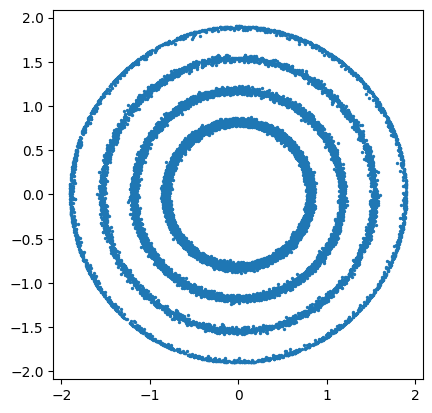

In [5]:
from matplotlib import pyplot as plt
plt.scatter(X[:,0], X[:,1], s=2)
plt.gca().set_aspect("equal")
plt.show()

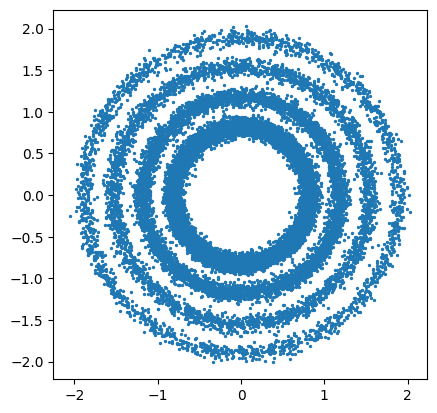

In [8]:
# add gaussian noise to the points
X_noisy = X + random.normal(key, (20_000, 2), dtype=jnp.float32) * 0.05
plt.scatter(X_noisy[:,0], X_noisy[:,1], s=2)
plt.gca().set_aspect("equal")
plt.show()